# E1 Structural Misspecification

This notebook presents the E1 experiment on structural misspecification. It reports the main SEIR-to-SIR transfer result, a severity analysis, a pseudo-truth reference ablation, and a compact summary figure. All computations reuse the workflow, diagnostics, and plotting utilities defined in `src/*.py`.

In [19]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "src").exists():
        ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate project root containing 'src'.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
OUTPUTS_ROOT = ROOT / "outputs"
print("Project root:", ROOT)
print("Outputs root:", OUTPUTS_ROOT)

from IPython.display import Markdown, display

from src.config import setup_environment
from src.diagnostics import evaluate_curve_level_ppc
from src.experiments import (
    build_E1_reference_ablation_summary,
    build_E1_results_report,
    build_E1_severity_summary,
    make_E1_case_simulator,
    run_E1_evaluation,
    run_E1_example_case,
    run_extended_E1_feature_evaluation,
)
from src.plotting import (
    plot_E1_ablation_comparison,
    plot_E1_severity_3panel_summary,
    plot_E1_severity_single_line,
    plot_curve_level_ppc_summary,
    plot_e1_example_case,
    plot_e1_overall_figure,
    plot_feature_residuals,
    plot_training_loss,
    plot_truth_vs_median_scatter,
)
from src.simulators import simulate_curve
from src.workflow import train_workflow


Project root: /Users/jijiayi/Documents/25WS/GNN/GNN_Final_Project
Outputs root: /Users/jijiayi/Documents/25WS/GNN/GNN_Final_Project/outputs


In [20]:
missing = []
for pkg in ["bayesflow", "tensorflow", "keras"]:
    try:
        __import__(pkg)
        print(f"[ok] {pkg}")
    except Exception as e:
        missing.append(pkg)
        print(f"[missing] {pkg}: {e}")

if missing:
    print("\nInstall missing packages in the current kernel environment, for example:")
    print("python -m pip install bayesflow==2.0.7 tensorflow==2.17.0 keras==3.9.0")
else:
    print("\nBackend check passed.")

[ok] bayesflow
[ok] tensorflow
[ok] keras

Backend check passed.


In [21]:
# Optional install cell.
# Uncomment and run this cell if the backend packages are missing,
# then restart the kernel before continuing.

import sys
print(sys.executable)
# !{sys.executable} -m pip install bayesflow==2.0.7 tensorflow==2.17.0 keras==3.9.0 numpy==1.26.4 pandas==2.3.3 scipy==1.15.3 matplotlib==3.8.4 seaborn

/opt/anaconda3/envs/bayesflow311/bin/python


bayesflow: 2.0.7
tensorflow: 2.17.0
keras: 3.9.0
numpy: 1.26.4
pandas: 2.3.3
scipy: 1.15.3
matplotlib: 3.8.4


INFO:bayesflow:Building dataset from simulator instance of LambdaSimulator.
INFO:bayesflow:Building on a test batch.


Epoch 1/12
60/60 - 20s - 339ms/step - loss: 2.5321
Epoch 2/12
60/60 - 4s - 72ms/step - loss: 1.4835
Epoch 3/12
60/60 - 5s - 78ms/step - loss: 0.8538
Epoch 4/12
60/60 - 4s - 69ms/step - loss: 0.2132
Epoch 5/12
60/60 - 4s - 71ms/step - loss: 0.0919
Epoch 6/12
60/60 - 4s - 69ms/step - loss: -1.7987e-01
Epoch 7/12
60/60 - 4s - 67ms/step - loss: -4.2126e-01
Epoch 8/12
60/60 - 4s - 72ms/step - loss: -4.9899e-01
Epoch 9/12
60/60 - 5s - 78ms/step - loss: -6.9216e-01
Epoch 10/12
60/60 - 4s - 68ms/step - loss: -7.4699e-01
Epoch 11/12
60/60 - 4s - 67ms/step - loss: -8.5404e-01
Epoch 12/12
60/60 - 4s - 68ms/step - loss: -9.2118e-01


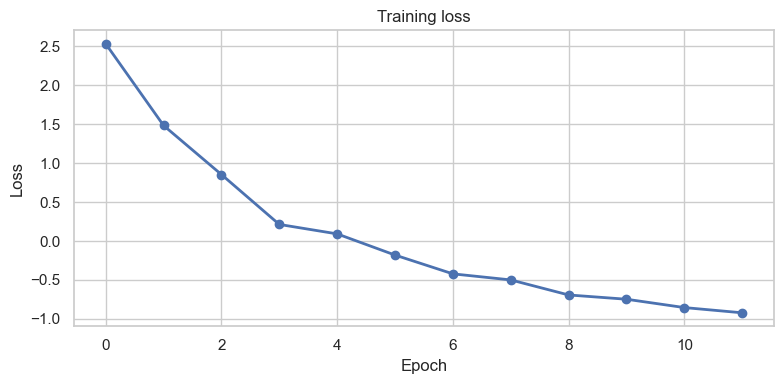

In [22]:
setup_environment(seed=42)
workflow_E0, history_E0 = train_workflow(seed=42)
plot_training_loss(history_E0)

## E1: Structural Misspecification

In E1, observations are generated by an SEIR model, whereas inference is still performed with the SIR-trained amortizer. Because SEIR and SIR do not share the same parameter space in a directly comparable way, recovery and coverage are evaluated against a projected pseudo-true SIR reference.

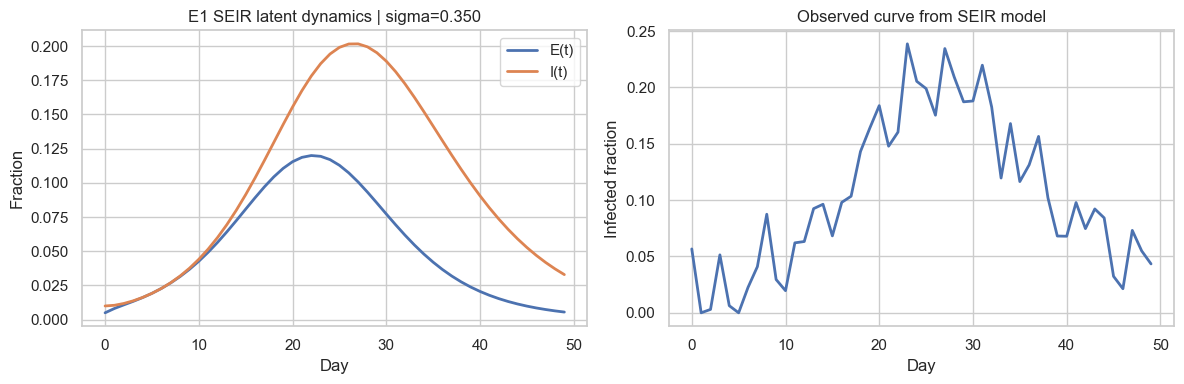

{'beta': 0.55, 'gamma': 0.18, 'sigma': 0.35, 'R0': 3.055555555555556, 'observed_curve': array([[0.05667229],
       [0.        ],
       [0.00300767],
       [0.05140534],
       [0.00631049],
       [0.        ],
       [0.02251832],
       [0.04096624],
       [0.08744821],
       [0.02952682],
       [0.01963224],
       [0.06207116],
       [0.06324832],
       [0.09242038],
       [0.09629975],
       [0.06825613],
       [0.09798209],
       [0.10344253],
       [0.14310555],
       [0.16399413],
       [0.1837904 ],
       [0.14781196],
       [0.16030636],
       [0.23863013],
       [0.20541011],
       [0.19892663],
       [0.17532912],
       [0.23445478],
       [0.20920064],
       [0.18719494],
       [0.18794735],
       [0.2196902 ],
       [0.18248507],
       [0.11958213],
       [0.16790062],
       [0.11643851],
       [0.13130882],
       [0.1565005 ],
       [0.1020299 ],
       [0.06811753],
       [0.06793101],
       [0.09781495],
       [0.0746909 ],
       [0

In [23]:
example_case = run_E1_example_case(beta=0.55, gamma=0.18, sigma=0.35, seed=3030)
plot_e1_example_case(
    example_case["seir_traj"],
    example_case["observed_curve"],
    example_case["time_grid"],
    example_case["sigma"],
    out_path=str(OUTPUTS_ROOT / "E1" / "E1_example_case.png"),
)
print(example_case)

This example case highlights the source of the mismatch. The exposed compartment introduces a latent delay before infections become visible, but the SIR inference model has no mechanism for representing that delay explicitly. As a result, the mismatch must be absorbed indirectly through the posterior over `beta` and `gamma`.

In [24]:
case_df, recovery_df, coverage_df, feature_case_df, feature_summary_df = run_E1_evaluation(
    workflow=workflow_E0,
    n_test=100,
    num_posterior_samples=2000,
    n_ppc_draws=100,
    seed=2026,
)
display(recovery_df.round(4))
display(coverage_df.round(4))
display(feature_summary_df.round(4))

,quantity,bias_mean_est,bias_median_est,MAE_median_est,RMSE_median_est,corr_truth_vs_median,avg_post_std
0,beta,0.0271,0.0216,0.0457,0.0739,0.8640,0.0480
1,gamma,0.0332,0.0390,0.0596,0.0994,0.6081,0.0521
2,R0,0.0190,0.0000,0.1388,0.2115,0.9837,0.2526


,quantity,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,avg_width50,avg_width90
0,beta,0.5,0.47,-0.03,0.9,0.79,-0.11,0.0671,0.1553
1,gamma,0.5,0.41,-0.09,0.9,0.85,-0.05,0.0770,0.1677
2,R0,0.5,0.65,0.15,0.9,0.95,0.05,0.3092,0.8283


,feature,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,bias_mean_pred,bias_median_pred,MAE_median_pred,RMSE_median_pred,avg_pred_std,avg_width50,avg_width90
0,peak_time,0.5,0.63,0.13,0.9,0.95,0.05,-1.4656,-1.7250,6.8350,10.0853,8.8502,14.3375,26.8225
1,peak_height,0.5,0.55,0.05,0.9,0.91,0.01,0.0028,-0.0001,0.0170,0.0254,0.0288,0.0302,0.0849
2,cumulative_infected,0.5,0.66,0.16,0.9,0.97,0.07,0.3092,0.2179,0.3504,0.6455,0.7083,0.6915,2.0797
3,early_growth_slope,0.5,0.45,-0.05,0.9,0.85,-0.05,0.0008,0.0008,0.0022,0.0028,0.0025,0.0034,0.0080


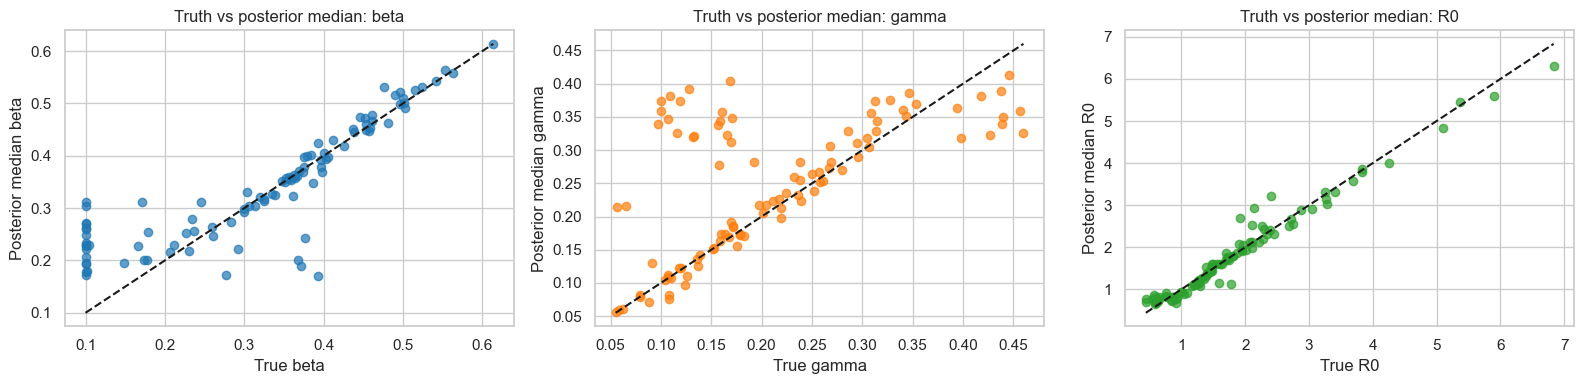

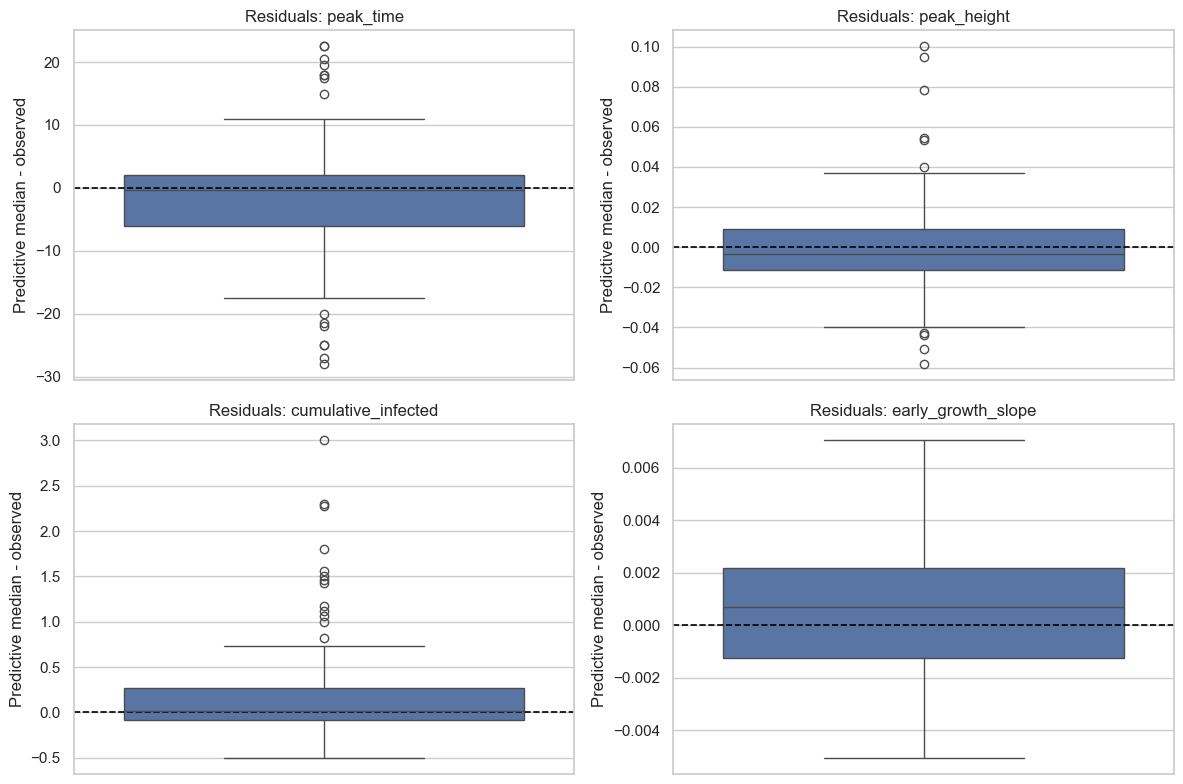

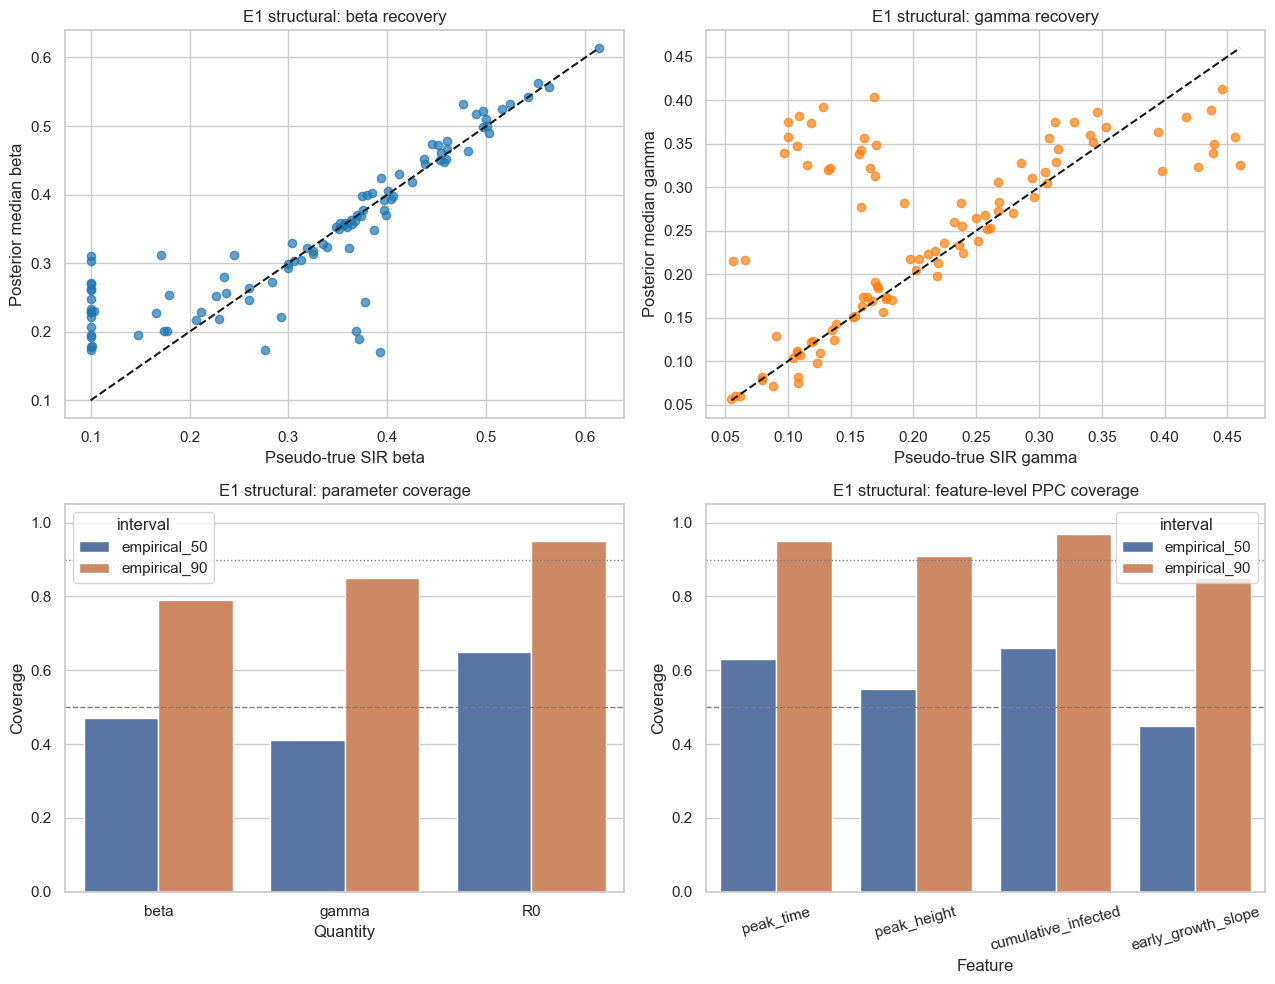

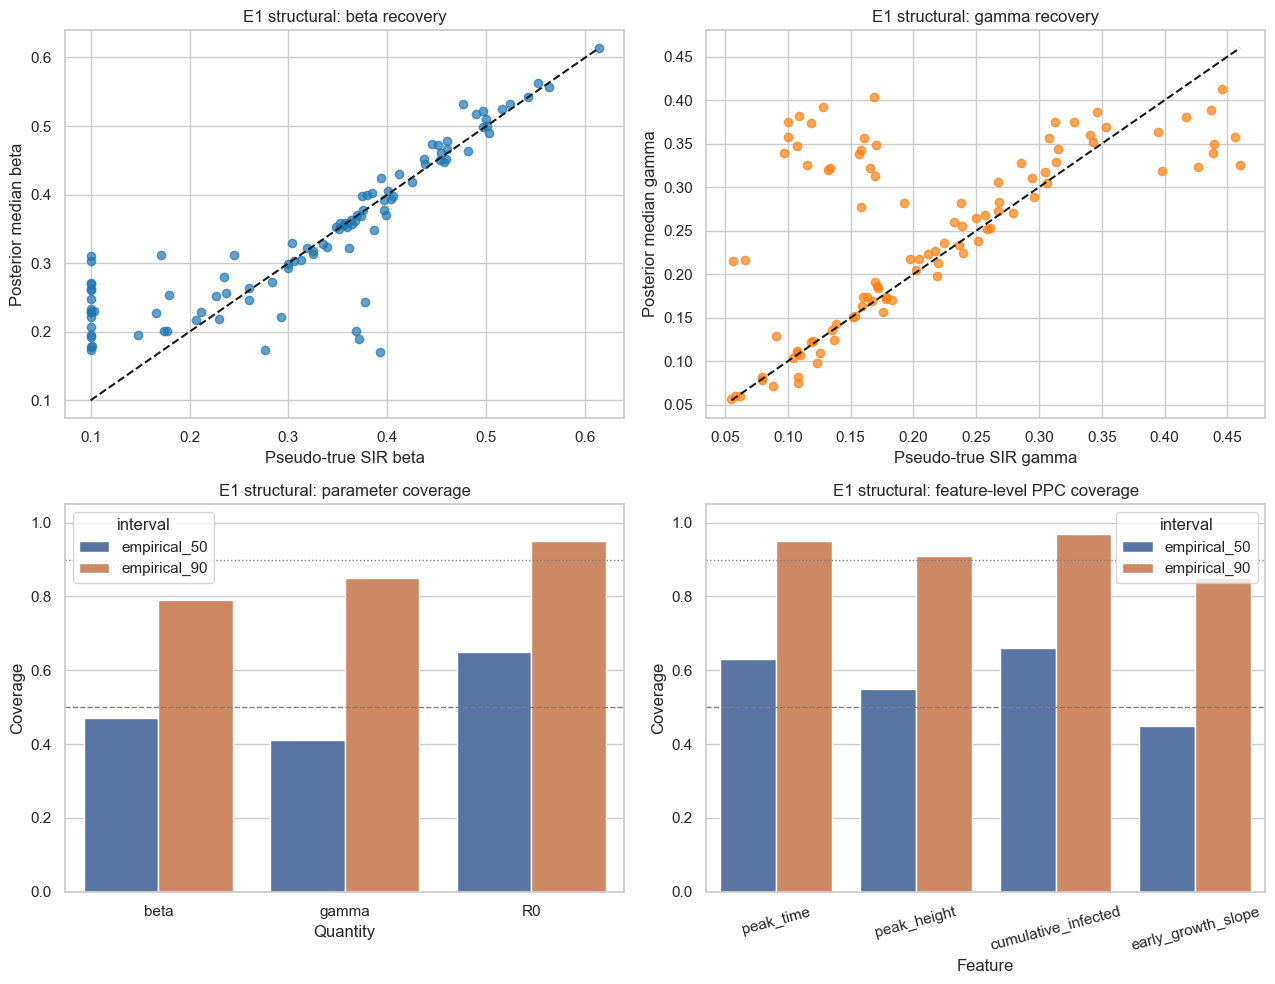

In [25]:
plot_truth_vs_median_scatter(case_df)
plot_feature_residuals(feature_case_df)
plot_e1_overall_figure(
    case_df,
    coverage_df,
    feature_summary_df,
    severity_label="structural",
    out_path=str(OUTPUTS_ROOT / "E1" / "E1_structural_overall_figure.png"),
)


This section reports the main E1 results. The central question is whether structural misspecification primarily harms parameter reliability, or whether it already causes obvious failures in coarse predictive summaries. In the current results, the main signal is a deterioration in posterior recovery and coverage, while several predictive summaries remain comparatively stable.

In [26]:
extended_feature_case_df, extended_feature_summary_df = run_extended_E1_feature_evaluation(
    workflow=workflow_E0,
    n_test=100,
    num_posterior_samples=1000,
    n_ppc_draws=100,
    seed=2026,
)
display(extended_feature_summary_df.round(4))

,feature,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,bias_mean_pred,bias_median_pred,MAE_median_pred,RMSE_median_pred,avg_pred_std,avg_width50,avg_width90
0,peak_time,0.5,0.62,0.12,0.9,0.93,0.03,-1.4544,-1.6400,7.0000,10.5131,8.9165,14.3925,27.1555
1,peak_height,0.5,0.58,0.08,0.9,0.93,0.03,0.0027,-0.0000,0.0168,0.0257,0.0292,0.0312,0.0847
2,cumulative_infected,0.5,0.65,0.15,0.9,0.97,0.07,0.3029,0.2133,0.3559,0.6596,0.7078,0.6965,2.0316
3,early_growth_slope,0.5,0.47,-0.03,0.9,0.84,-0.06,0.0008,0.0008,0.0022,0.0028,0.0025,0.0033,0.0081
4,post_peak_decline_slope,0.5,0.43,-0.07,0.9,0.84,-0.06,0.0007,0.0013,0.0033,0.0059,0.0049,0.0037,0.0118
5,late_phase_auc,0.5,0.61,0.11,0.9,0.98,0.08,0.2170,0.1502,0.2526,0.4968,0.5121,0.4732,1.4281
6,time_to_half_peak_after_peak,0.5,0.74,0.24,0.9,0.95,0.05,0.8037,0.3800,1.2400,2.2372,2.3551,2.4150,6.5740
7,late_to_early_mean_ratio,0.5,0.55,0.05,0.9,0.95,0.05,-0.0623,-0.1392,0.2346,0.3449,0.4376,0.4533,1.3171


We next extend the PPC analysis with more shape-sensitive summaries. These additional diagnostics are intended to test whether structural mismatch becomes more visible in post-peak behavior, late-phase mass, and timing-related features that are less apparent in the original coarse summary set.

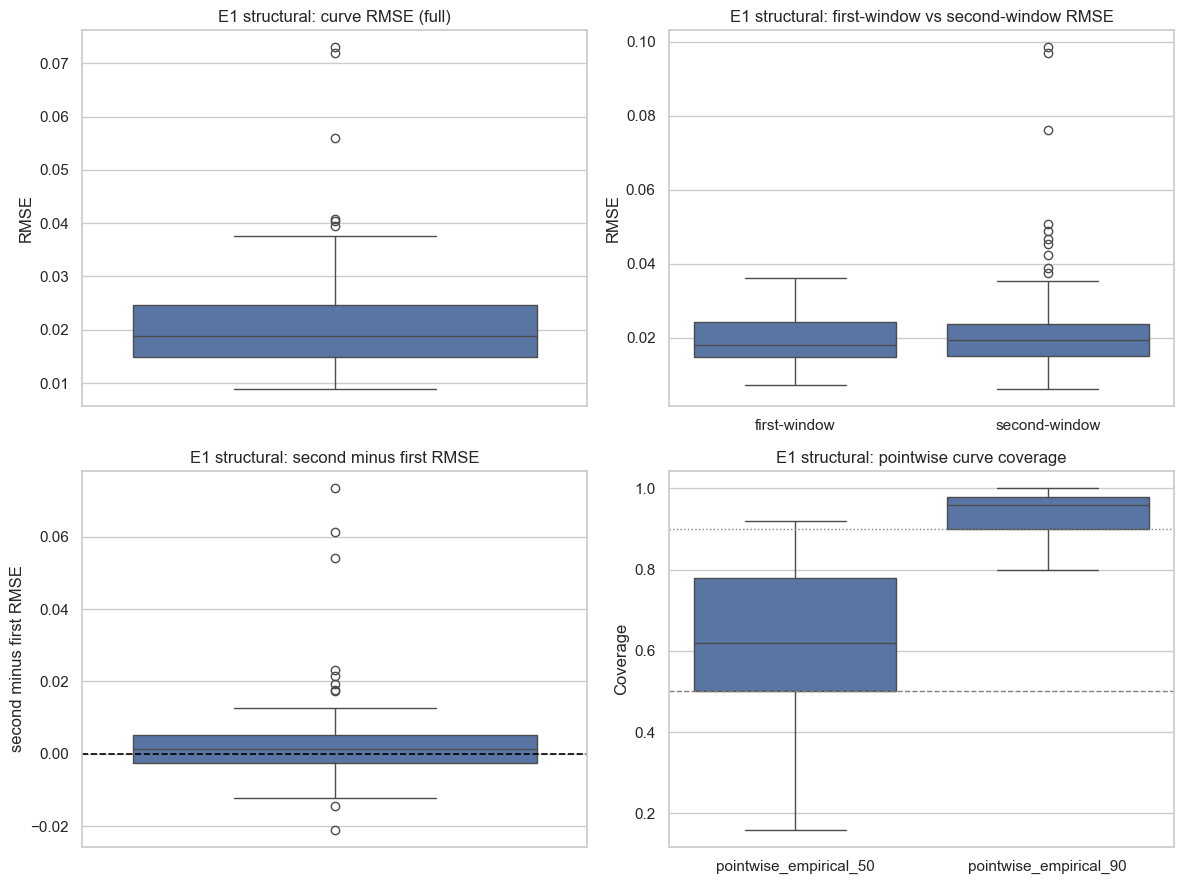

,metric,mean,std,median,q05,q95
0,pointwise_empirical_50,0.6286,0.1699,0.6200,0.3800,0.8610
1,pointwise_empirical_90,0.9414,0.0553,0.9600,0.8200,1.0000
2,curve_bias_full,0.0025,0.0127,-0.0023,-0.0075,0.0304
3,curve_mae_full,0.0169,0.0091,0.0152,0.0078,0.0338
4,curve_rmse_full,0.0214,0.0107,0.0189,0.0111,0.0396
5,curve_bias_first,0.0003,0.0080,-0.0024,-0.0095,0.0141
6,curve_mae_first,0.0154,0.0055,0.0151,0.0080,0.0263
7,curve_rmse_first,0.0193,0.0065,0.0181,0.0103,0.0316
8,curve_bias_second,0.0046,0.0193,-0.0020,-0.0103,0.0421
9,curve_mae_second,0.0184,0.0147,0.0151,0.0074,0.0422


In [27]:
curve_case_df, curve_summary_df = evaluate_curve_level_ppc(
    workflow=workflow_E0,
    case_simulator=make_E1_case_simulator(),
    predictive_curve_simulator=simulate_curve,
    n_test=100,
    num_posterior_samples=1000,
    n_ppc_draws=100,
    seed=2026,
    split_frac=0.5,
)
plot_curve_level_ppc_summary(
    curve_case_df,
    severity_label="structural",
    experiment_label="E1",
    out_dir=str(OUTPUTS_ROOT / "E1" / "curve_level"),
)
display(curve_summary_df.round(4))


Curve-level PPC addresses a stricter version of the same question: can posterior predictive trajectories still look acceptable even when parameter posteriors are already distorted? For E1, the answer is largely yes. This makes curve-level analysis especially useful, because it shows that visually reasonable fit does not guarantee reliable posterior inference.

In [28]:
report_text = build_E1_results_report(
    recovery_df=recovery_df,
    coverage_df=coverage_df,
    feature_summary_df=feature_summary_df,
    curve_summary_df=curve_summary_df,
)
display(Markdown(report_text))

# E1 Structural Misspecification Report

## Setup

- Truth model: SEIR
- Inference model: SIR-trained BayesFlow amortizer
- Purpose: evaluate structural misspecification caused by ignoring the exposed compartment

## Key Findings

- Posterior median bias:
  - beta: 0.0216
  - gamma: 0.0390
  - R0: 0.0000
- Empirical 90% coverage:
  - beta: 0.7900
  - gamma: 0.8500
  - R0: 0.9500
- Feature-level PPC:
  - peak_time empirical 90% coverage: 0.9500
  - early_growth_slope empirical 50% coverage: 0.4500
- Curve-level PPC:
  - mean full-curve RMSE: 0.0214
  - mean pointwise empirical 90% coverage: 0.9414

## Interpretation

Under E1, the inference model is forced to explain SEIR-generated observations with a simpler SIR family. This primarily tests whether the missing latent exposure stage distorts parameter recovery, narrows posterior intervals too aggressively, or creates predictive mismatches that are more visible in feature-level or curve-level diagnostics than in matched settings.

In practice, the report should be interpreted by comparing transmission-related quantities, recovery-related quantities, and predictive diagnostics together rather than relying on a single metric alone.


In [29]:
E1_OUTPUT_DIR = OUTPUTS_ROOT / "E1"
E1_CURVE_DIR = E1_OUTPUT_DIR / "curve_level"
os.makedirs(E1_OUTPUT_DIR, exist_ok=True)
os.makedirs(E1_CURVE_DIR, exist_ok=True)
case_df.to_csv(E1_OUTPUT_DIR / "E1_case_level.csv", index=False)
recovery_df.to_csv(E1_OUTPUT_DIR / "E1_recovery_summary.csv", index=False)
coverage_df.to_csv(E1_OUTPUT_DIR / "E1_coverage_summary.csv", index=False)
feature_case_df.to_csv(E1_OUTPUT_DIR / "E1_ppc_feature_case_level.csv", index=False)
feature_summary_df.to_csv(E1_OUTPUT_DIR / "E1_ppc_feature_summary.csv", index=False)
extended_feature_case_df.to_csv(E1_OUTPUT_DIR / "E1_ppc_feature_case_level_extended.csv", index=False)
extended_feature_summary_df.to_csv(E1_OUTPUT_DIR / "E1_ppc_feature_summary_extended.csv", index=False)
curve_case_df.to_csv(E1_CURVE_DIR / "E1_curve_case_level.csv", index=False)
curve_summary_df.to_csv(E1_CURVE_DIR / "E1_curve_summary.csv", index=False)
with open(E1_OUTPUT_DIR / "E1_results_report.md", "w") as f:
    f.write(report_text)
print("Saved E1 outputs and report.")

Saved E1 outputs and report.


## E1-main: Severity Version

We now vary the strength of structural misspecification using `mild`, `medium`, and `strong` severity settings while keeping `reference_mode="full_curve"` fixed. The purpose is to test whether posterior bias and under-coverage worsen systematically as the latent exposed stage becomes more influential.

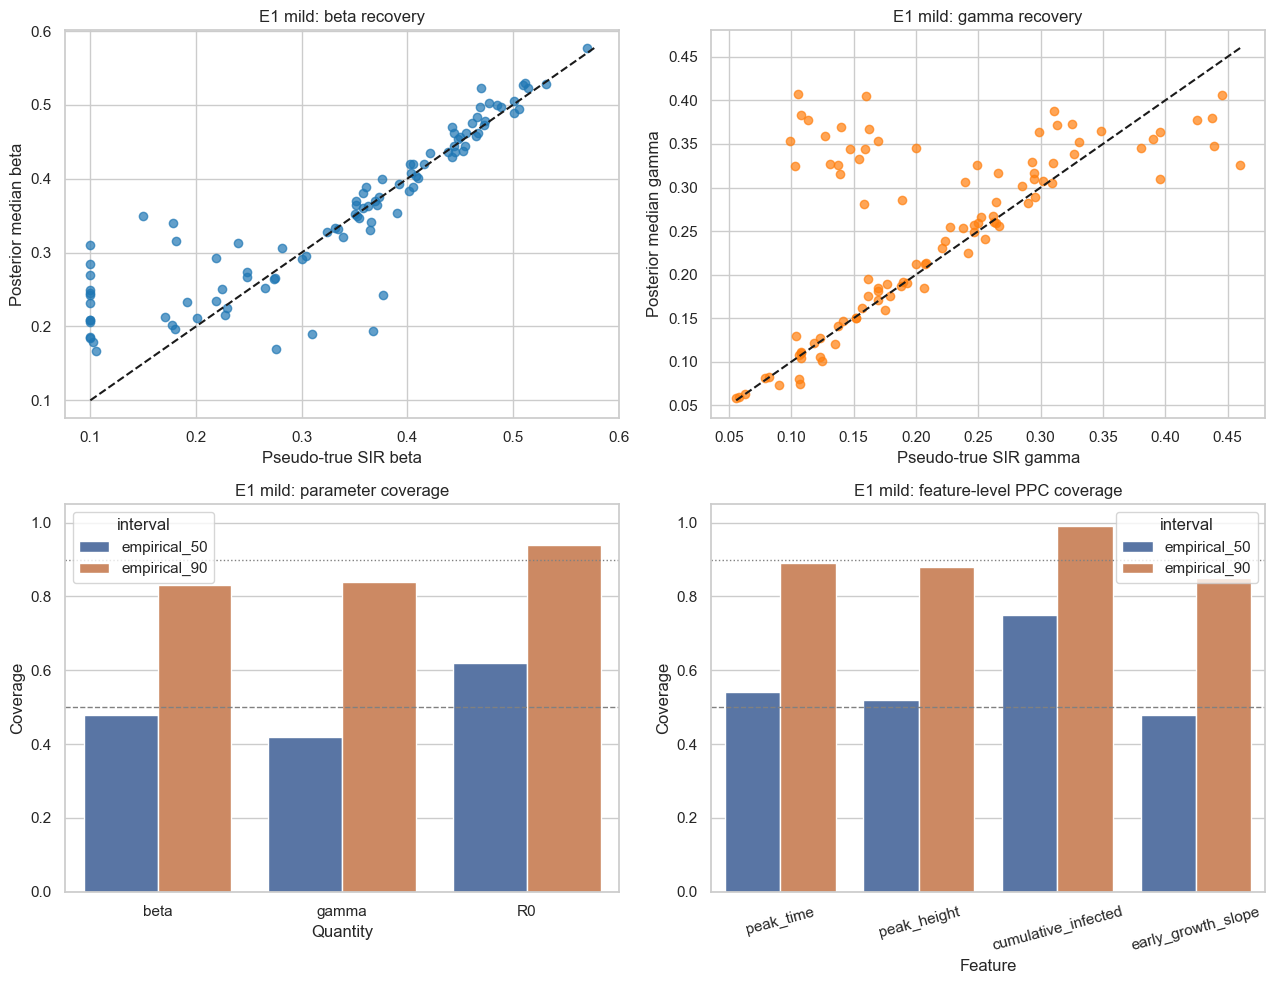

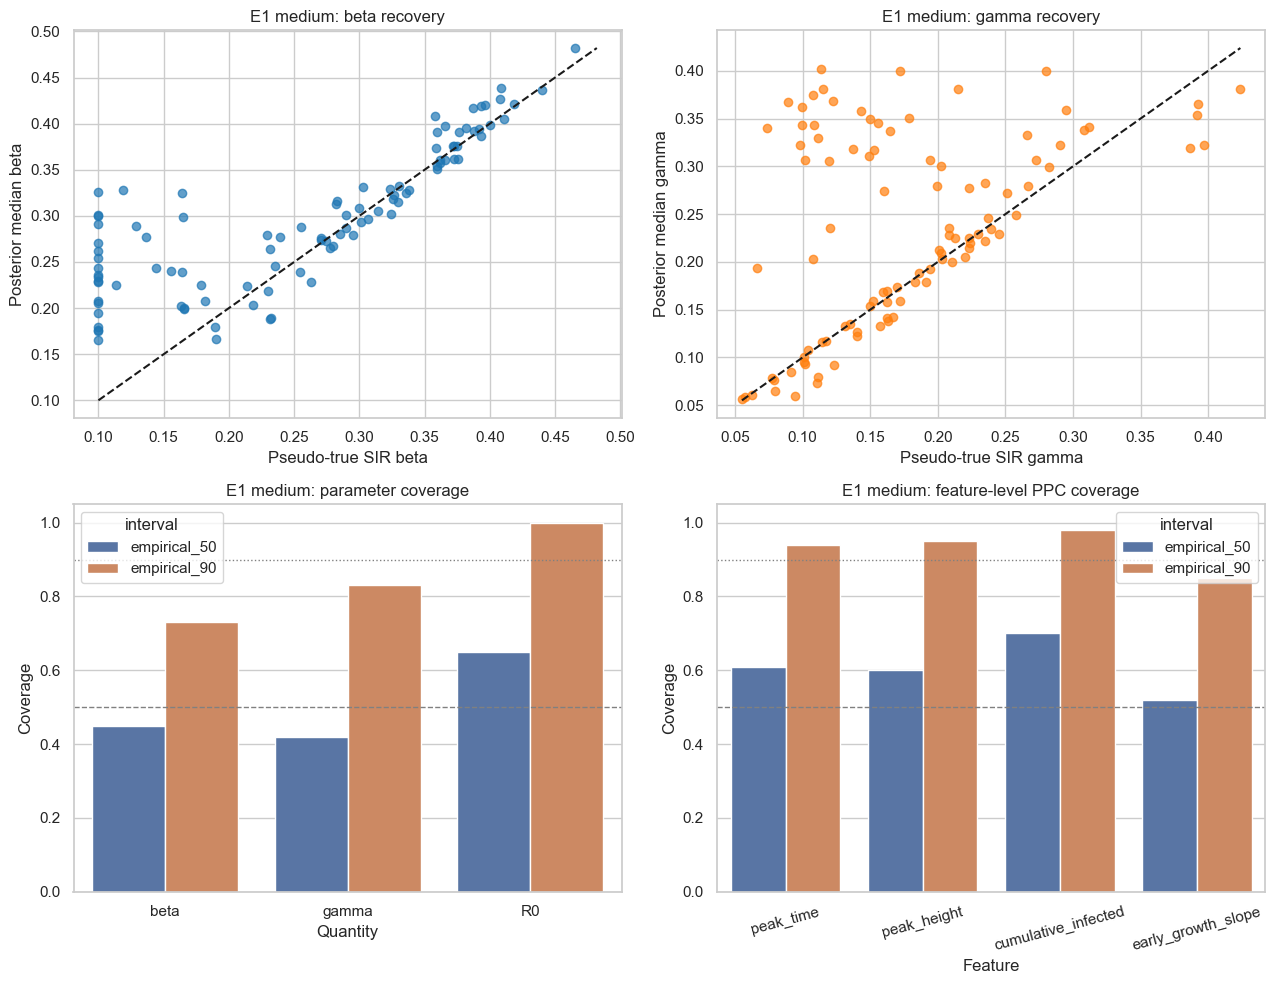

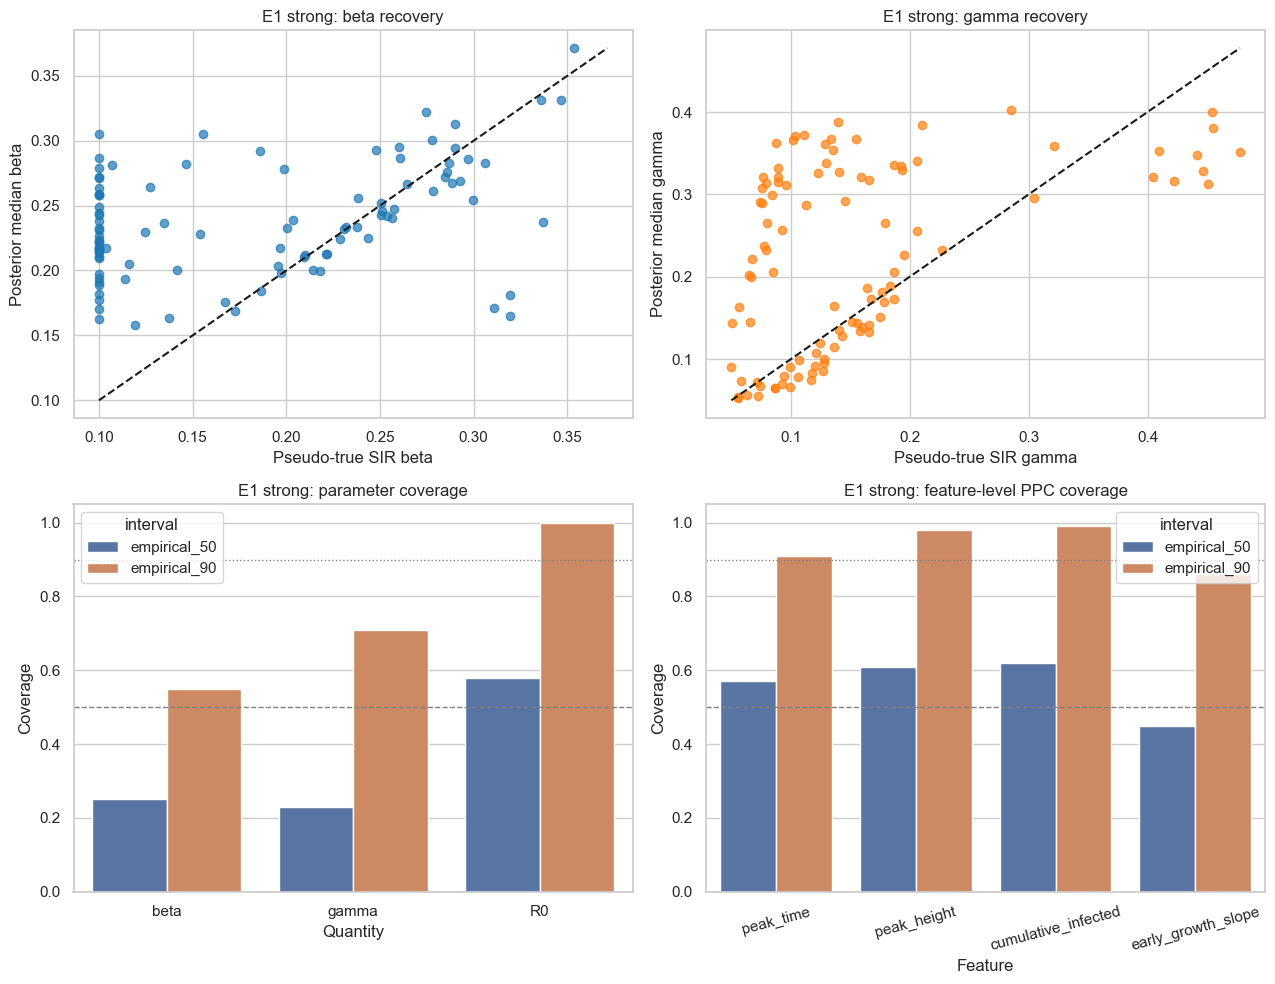

In [30]:
severity_outputs_E1 = {}
for severity in ["mild", "medium", "strong"]:
    case_df_E1, recovery_df_E1, coverage_df_E1, feature_case_df_E1, feature_summary_df_E1 = run_E1_evaluation(
        workflow=workflow_E0,
        severity=severity,
        reference_mode="full_curve",
        n_test=100,
        num_posterior_samples=2000,
        n_ppc_draws=100,
        seed=2026,
    )
    severity_outputs_E1[severity] = {
        "case_df": case_df_E1,
        "recovery_df": recovery_df_E1,
        "coverage_df": coverage_df_E1,
        "feature_case_df": feature_case_df_E1,
        "feature_summary_df": feature_summary_df_E1,
    }
    out_dir = OUTPUTS_ROOT / "E1" / severity
    out_dir.mkdir(parents=True, exist_ok=True)
    case_df_E1.to_csv(out_dir / "E1_case_level.csv", index=False)
    recovery_df_E1.to_csv(out_dir / "E1_recovery_summary.csv", index=False)
    coverage_df_E1.to_csv(out_dir / "E1_coverage_summary.csv", index=False)
    feature_case_df_E1.to_csv(out_dir / "E1_ppc_feature_case_level.csv", index=False)
    feature_summary_df_E1.to_csv(out_dir / "E1_ppc_feature_summary.csv", index=False)
    plot_e1_overall_figure(
        case_df_E1,
        coverage_df_E1,
        feature_summary_df_E1,
        severity_label=severity,
        out_path=str(out_dir / "E1_overall_figure.png"),
    )


In [31]:
E1_severity_summary_df = build_E1_severity_summary(
    mild_recovery_df_E1=severity_outputs_E1["mild"]["recovery_df"],
    mild_coverage_df_E1=severity_outputs_E1["mild"]["coverage_df"],
    mild_feature_summary_df_E1=severity_outputs_E1["mild"]["feature_summary_df"],
    medium_recovery_df_E1=severity_outputs_E1["medium"]["recovery_df"],
    medium_coverage_df_E1=severity_outputs_E1["medium"]["coverage_df"],
    medium_feature_summary_df_E1=severity_outputs_E1["medium"]["feature_summary_df"],
    strong_recovery_df_E1=severity_outputs_E1["strong"]["recovery_df"],
    strong_coverage_df_E1=severity_outputs_E1["strong"]["coverage_df"],
    strong_feature_summary_df_E1=severity_outputs_E1["strong"]["feature_summary_df"],
)
severity_dir_E1 = OUTPUTS_ROOT / "E1" / "severity_summary"
severity_dir_E1.mkdir(parents=True, exist_ok=True)
E1_severity_summary_df.to_csv(severity_dir_E1 / "E1_severity_summary.csv", index=False)
display(E1_severity_summary_df.round(4))


,severity,beta_bias_median,beta_MAE,R0_MAE,beta_empirical_90,gamma_empirical_90,R0_empirical_90,peak_time_MAE,early_growth_slope_empirical_50
0,mild,0.0225,0.0399,0.1330,0.83,0.84,0.94,6.765,0.48
1,medium,0.0414,0.0496,0.1673,0.73,0.83,1.00,7.290,0.52
2,strong,0.0544,0.0714,0.2673,0.55,0.71,1.00,8.885,0.45


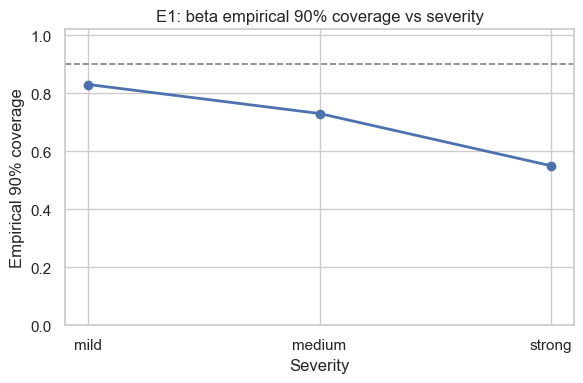

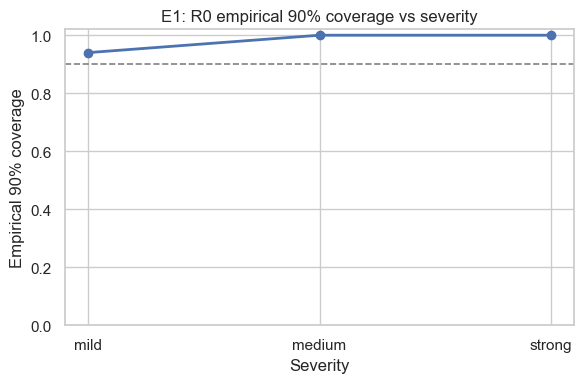

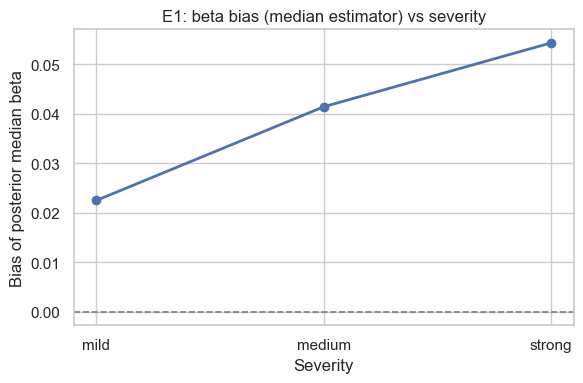

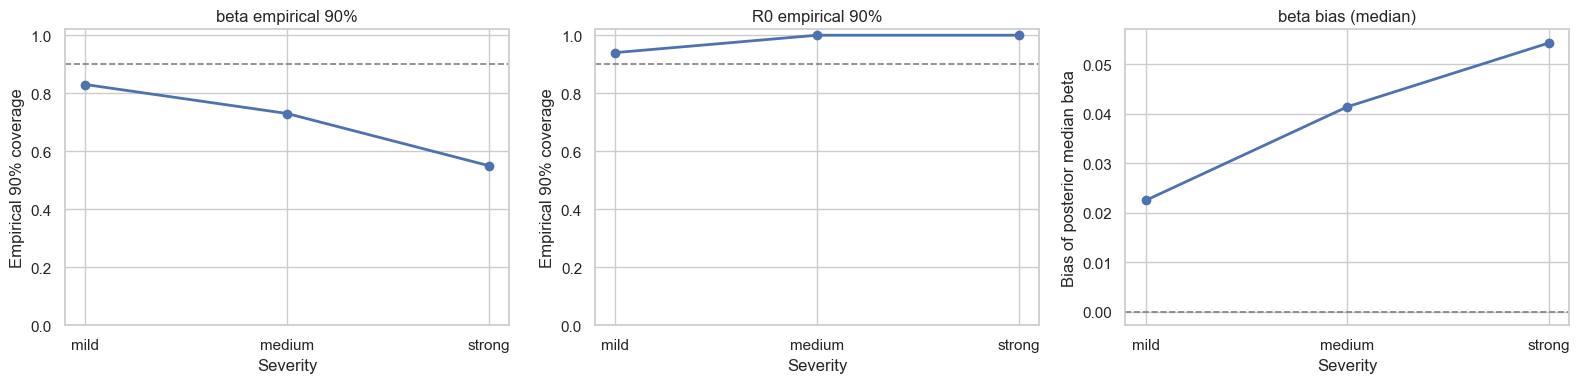

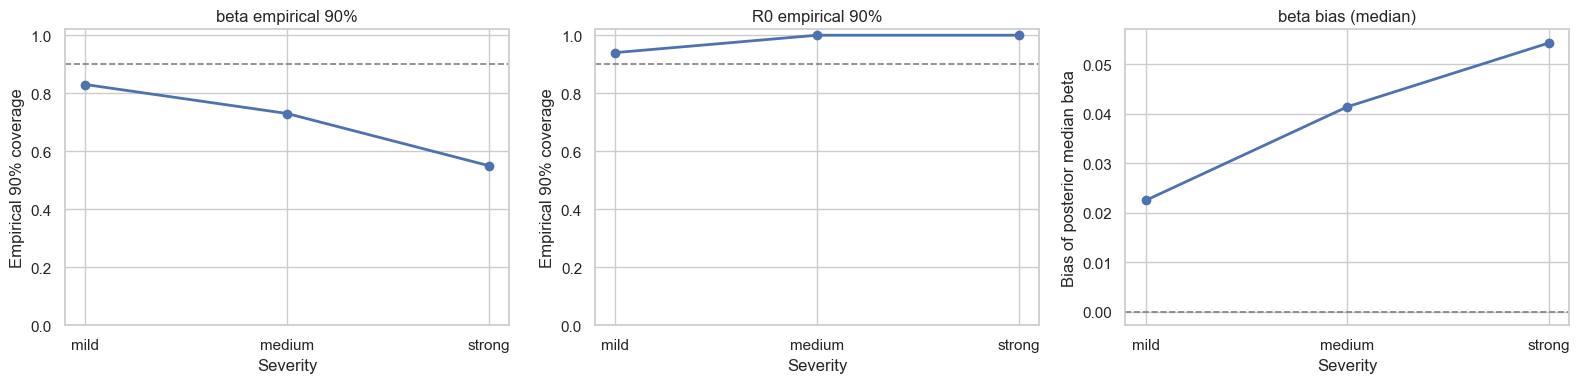

In [32]:
plot_E1_severity_single_line(
    E1_severity_summary_df,
    metric="beta_empirical_90",
    out_path=str(OUTPUTS_ROOT / "E1" / "severity_summary" / "E1_beta_empirical90_vs_severity.png"),
)
plot_E1_severity_single_line(
    E1_severity_summary_df,
    metric="R0_empirical_90",
    out_path=str(OUTPUTS_ROOT / "E1" / "severity_summary" / "E1_R0_empirical90_vs_severity.png"),
)
plot_E1_severity_single_line(
    E1_severity_summary_df,
    metric="beta_bias_median",
    out_path=str(OUTPUTS_ROOT / "E1" / "severity_summary" / "E1_beta_bias_median_vs_severity.png"),
)
plot_E1_severity_3panel_summary(
    E1_severity_summary_df,
    out_path=str(OUTPUTS_ROOT / "E1" / "severity_summary" / "E1_severity_3panel_summary.png"),
)


## E1-ablation-1: Pseudo-Truth Definition

Here we fix `severity="medium"` and compare two pseudo-truth definitions: `full_curve` and `early_phase`. This ablation checks whether the main E1 conclusions are robust to the specific projection window used to define the SIR reference.

In [33]:
reference_outputs_E1 = {}
for reference_mode in ["full_curve", "early_phase"]:
    case_df_ref, recovery_df_ref, coverage_df_ref, feature_case_df_ref, feature_summary_df_ref = run_E1_evaluation(
        workflow=workflow_E0,
        severity="medium",
        reference_mode=reference_mode,
        n_test=100,
        num_posterior_samples=2000,
        n_ppc_draws=100,
        seed=2026,
    )
    reference_outputs_E1[reference_mode] = {
        "case_df": case_df_ref,
        "recovery_df": recovery_df_ref,
        "coverage_df": coverage_df_ref,
        "feature_case_df": feature_case_df_ref,
        "feature_summary_df": feature_summary_df_ref,
    }
    out_dir = OUTPUTS_ROOT / "E1" / "ablation_reference" / reference_mode
    out_dir.mkdir(parents=True, exist_ok=True)
    case_df_ref.to_csv(out_dir / "E1_case_level.csv", index=False)
    recovery_df_ref.to_csv(out_dir / "E1_recovery_summary.csv", index=False)
    coverage_df_ref.to_csv(out_dir / "E1_coverage_summary.csv", index=False)
    feature_case_df_ref.to_csv(out_dir / "E1_ppc_feature_case_level.csv", index=False)
    feature_summary_df_ref.to_csv(out_dir / "E1_ppc_feature_summary.csv", index=False)

E1_reference_ablation_df = build_E1_reference_ablation_summary(
    full_curve_recovery_df_E1=reference_outputs_E1["full_curve"]["recovery_df"],
    full_curve_coverage_df_E1=reference_outputs_E1["full_curve"]["coverage_df"],
    full_curve_feature_summary_df_E1=reference_outputs_E1["full_curve"]["feature_summary_df"],
    early_phase_recovery_df_E1=reference_outputs_E1["early_phase"]["recovery_df"],
    early_phase_coverage_df_E1=reference_outputs_E1["early_phase"]["coverage_df"],
    early_phase_feature_summary_df_E1=reference_outputs_E1["early_phase"]["feature_summary_df"],
)
reference_dir_E1 = OUTPUTS_ROOT / "E1" / "ablation_reference"
reference_dir_E1.mkdir(parents=True, exist_ok=True)
E1_reference_ablation_df.to_csv(reference_dir_E1 / "E1_ablation_reference_summary.csv", index=False)
display(E1_reference_ablation_df.round(4))


,reference_mode,beta_bias_median,beta_MAE,R0_MAE,beta_empirical_90,gamma_empirical_90,R0_empirical_90,peak_time_MAE,early_growth_slope_empirical_50
0,full_curve,0.0414,0.0492,0.1677,0.73,0.84,1.00,7.11,0.48
1,early_phase,0.0975,0.1287,0.7976,0.36,0.36,0.55,6.91,0.47


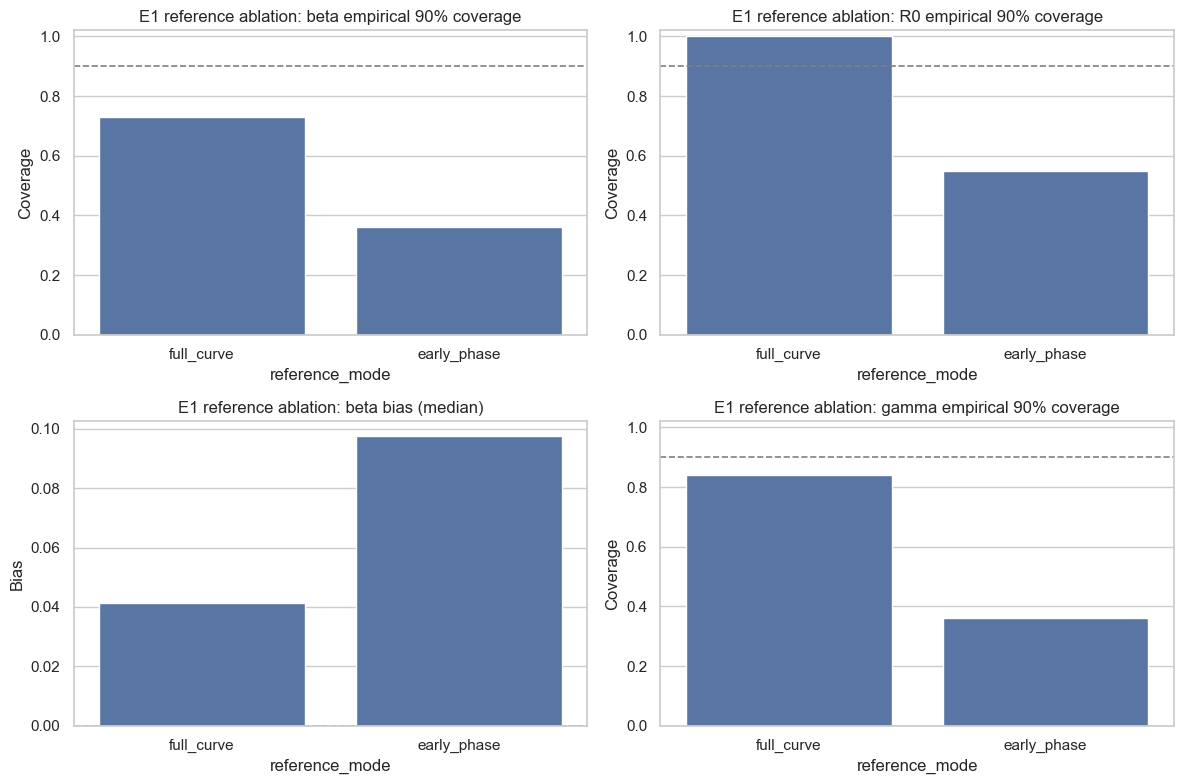

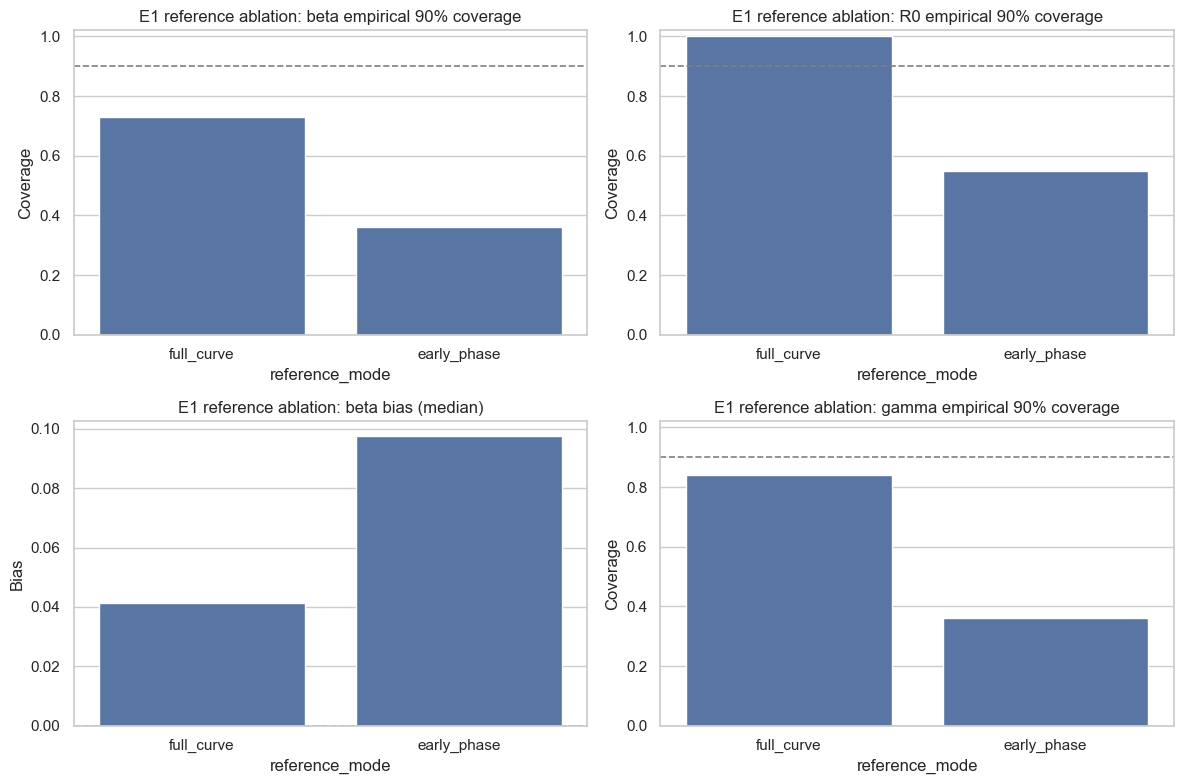

In [34]:
plot_E1_ablation_comparison(
    E1_reference_ablation_df,
    group_col="reference_mode",
    title_prefix="E1 reference ablation",
    out_path=str(OUTPUTS_ROOT / "E1" / "ablation_reference" / "E1_ablation_reference_comparison.png"),
)


## E1 4-Panel Summary Figure

This figure is intended to serve as the main report figure for E1. It summarizes the key result of the experiment: structural misspecification can produce biased and under-covered parameter posteriors even when posterior predictive curves still appear adequate in the observation space.

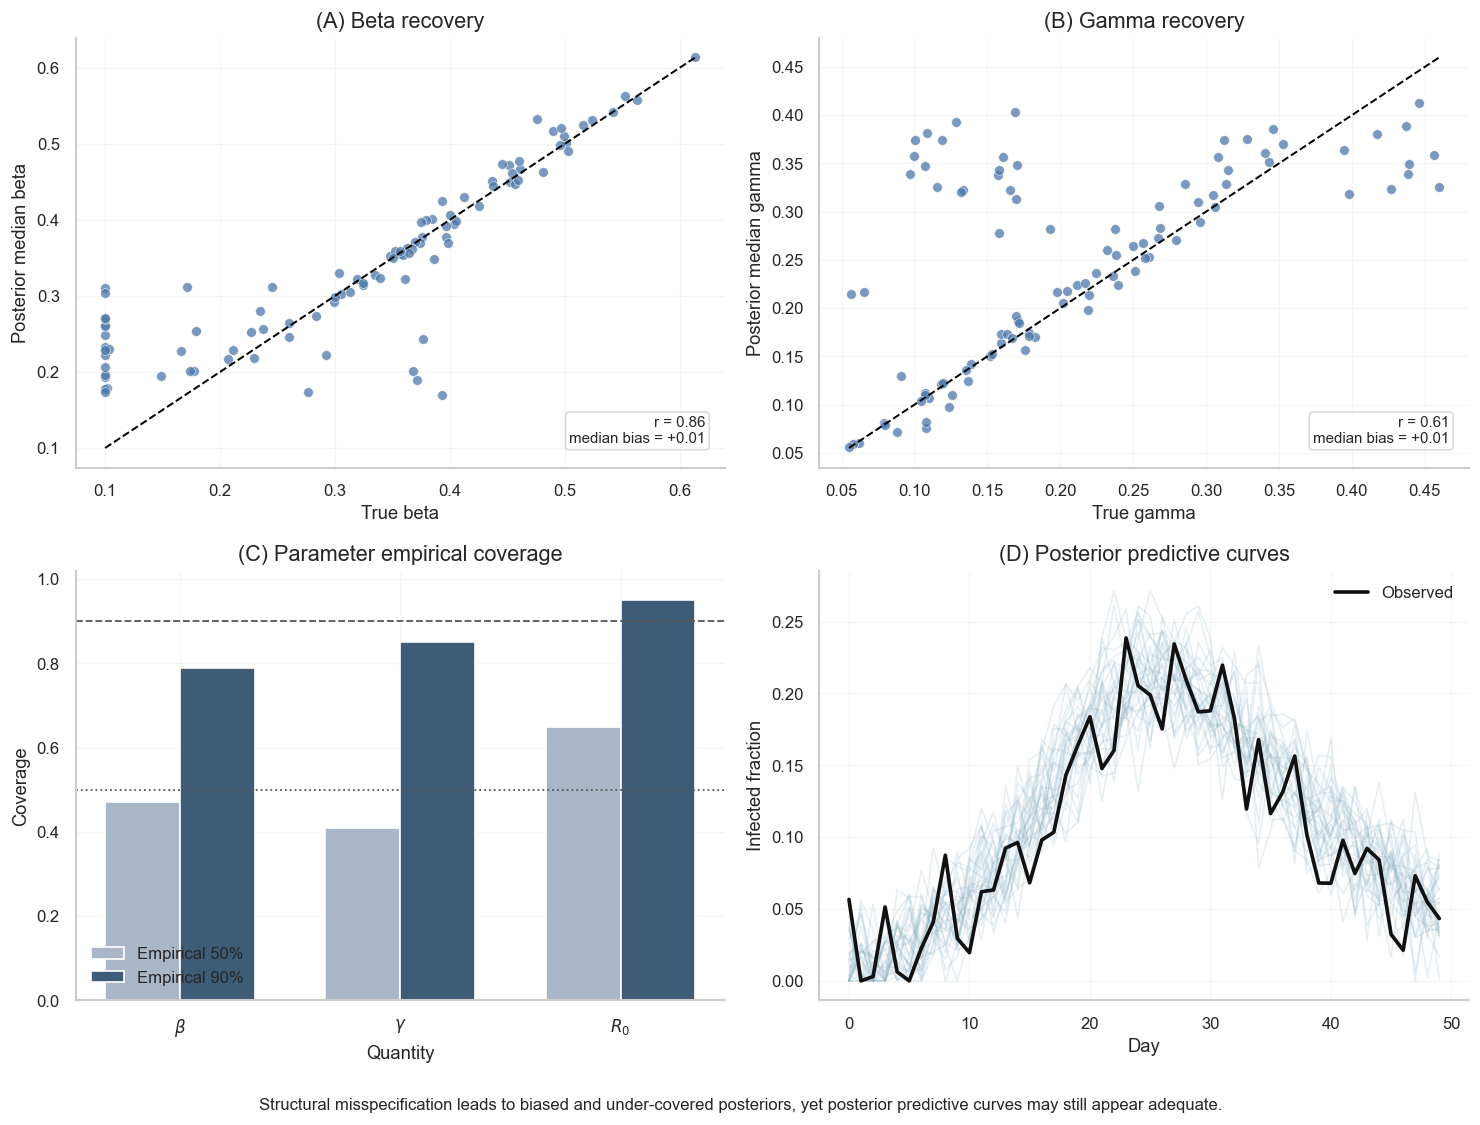

In [37]:
# E1 main message:
# structural misspecification leads to biased and under-covered posteriors,
# yet posterior predictive curves may still appear adequate.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

# --- Resolve predictive objects with notebook-friendly fallbacks ---
if "observed_curve" not in globals():
    if "example_case" in globals() and "observed_curve" in example_case:
        observed_curve = np.asarray(example_case["observed_curve"])
    else:
        raise NameError("Need `observed_curve` or `example_case['observed_curve']` for Panel D.")

if "posterior_predictive_samples" not in globals():
    posterior_predictive_samples = None
    try:
        from src.workflow import sample_posterior

        if "workflow_E0" in globals():
            posterior_draws = sample_posterior(workflow_E0, observed_curve, num_samples=200)
            rng_pp = np.random.default_rng(2026)
            posterior_predictive_samples = np.asarray(
                [simulate_curve(float(beta), float(gamma), rng=rng_pp)
                 for beta, gamma in zip(posterior_draws["beta"], posterior_draws["gamma"])])
    except Exception as e:
        print(f"Predictive-curve fallback unavailable: {e}")
        posterior_predictive_samples = None

# --- Figure style ---
scatter_color = "#4C78A8"
coverage50_color = "#A8B6C8"
coverage90_color = "#3E5C76"
predictive_color = "#7EA8BE"
obs_color = "#111111"

def _style_axis(ax):
    ax.grid(True, alpha=0.18, linewidth=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig, axes = plt.subplots(2, 2, figsize=(12.5, 9.5))
ax_a, ax_b, ax_c, ax_d = axes.flatten()

# --- Panel A: beta recovery ---
ax_a.scatter(
    case_df["true_beta"],
    case_df["beta_median"],
    s=34,
    alpha=0.75,
    color=scatter_color,
    edgecolor="white",
    linewidth=0.4,
)
lo = min(case_df["true_beta"].min(), case_df["beta_median"].min())
hi = max(case_df["true_beta"].max(), case_df["beta_median"].max())
ax_a.plot([lo, hi], [lo, hi], linestyle="--", color="black", linewidth=1.2)
ax_a.set_title("(A) Beta recovery")
ax_a.set_xlabel("True beta")
ax_a.set_ylabel("Posterior median beta")
_style_axis(ax_a)

beta_corr = case_df[["true_beta", "beta_median"]].corr().iloc[0, 1]
beta_bias = np.median(case_df["beta_median"] - case_df["true_beta"])
ax_a.text(
    0.97,
    0.05,
    f"r = {beta_corr:.2f}\nmedian bias = {beta_bias:+.2f}",
    transform=ax_a.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.85", alpha=0.95),
)

# --- Panel B: gamma recovery ---
ax_b.scatter(
    case_df["true_gamma"],
    case_df["gamma_median"],
    s=34,
    alpha=0.75,
    color=scatter_color,
    edgecolor="white",
    linewidth=0.4,
)
lo = min(case_df["true_gamma"].min(), case_df["gamma_median"].min())
hi = max(case_df["true_gamma"].max(), case_df["gamma_median"].max())
ax_b.plot([lo, hi], [lo, hi], linestyle="--", color="black", linewidth=1.2)
ax_b.set_title("(B) Gamma recovery")
ax_b.set_xlabel("True gamma")
ax_b.set_ylabel("Posterior median gamma")
_style_axis(ax_b)

gamma_corr = case_df[["true_gamma", "gamma_median"]].corr().iloc[0, 1]
gamma_bias = np.median(case_df["gamma_median"] - case_df["true_gamma"])
ax_b.text(
    0.97,
    0.05,
    f"r = {gamma_corr:.2f}\nmedian bias = {gamma_bias:+.2f}",
    transform=ax_b.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.85", alpha=0.95),
)

# --- Panel C: parameter empirical coverage ---
coverage_order = ["beta", "gamma", "R0"]
coverage_plot_df = coverage_df.copy()
coverage_plot_df = coverage_plot_df.set_index("quantity").loc[coverage_order].reset_index()

x = np.arange(len(coverage_plot_df))
width = 0.34
ax_c.bar(x - width/2, coverage_plot_df["empirical_50"], width=width, color=coverage50_color, label="Empirical 50%")
ax_c.bar(x + width/2, coverage_plot_df["empirical_90"], width=width, color=coverage90_color, label="Empirical 90%")
ax_c.axhline(0.50, color="0.35", linestyle=":", linewidth=1.1)
ax_c.axhline(0.90, color="0.35", linestyle="--", linewidth=1.1)
ax_c.set_xticks(x)
ax_c.set_xticklabels([r"$\beta$", r"$\gamma$", r"$R_0$"])
ax_c.set_ylim(0, 1.02)
ax_c.set_title("(C) Parameter empirical coverage")
ax_c.set_xlabel("Quantity")
ax_c.set_ylabel("Coverage")
ax_c.legend(frameon=False, loc="lower left")
_style_axis(ax_c)

# --- Panel D: predictive adequacy ---
curve_panel_drawn = posterior_predictive_samples is not None and np.size(posterior_predictive_samples) > 0
if curve_panel_drawn:
    posterior_predictive_samples = np.asarray(posterior_predictive_samples)
    rng = np.random.default_rng(2026)
    n_draw = min(30, posterior_predictive_samples.shape[0])
    draw_idx = rng.choice(posterior_predictive_samples.shape[0], size=n_draw, replace=False)
    time_grid = np.arange(np.asarray(observed_curve).shape[0])

    for idx in draw_idx:
        ax_d.plot(time_grid, posterior_predictive_samples[idx], color=predictive_color, alpha=0.18, linewidth=1.0)
    ax_d.plot(time_grid, observed_curve, color=obs_color, linewidth=2.2, label="Observed")
    ax_d.set_title("(D) Posterior predictive curves")
    ax_d.set_xlabel("Day")
    ax_d.set_ylabel("Infected fraction")
    ax_d.legend(frameon=False, loc="upper right")
else:
    feature_order = feature_summary_df.sort_values("empirical_90")["feature"].tolist()
    feature_plot_df = feature_summary_df.set_index("feature").loc[feature_order].reset_index()
    xf = np.arange(len(feature_plot_df))
    width_f = 0.34
    ax_d.bar(xf - width_f/2, feature_plot_df["empirical_50"], width=width_f, color=coverage50_color, label="Empirical 50%")
    ax_d.bar(xf + width_f/2, feature_plot_df["empirical_90"], width=width_f, color=coverage90_color, label="Empirical 90%")
    ax_d.axhline(0.50, color="0.35", linestyle=":", linewidth=1.1)
    ax_d.axhline(0.90, color="0.35", linestyle="--", linewidth=1.1)
    ax_d.set_xticks(xf)
    ax_d.set_xticklabels(feature_plot_df["feature"], rotation=20, ha="right")
    ax_d.set_ylim(0, 1.02)
    ax_d.set_title("(D) Feature-level PPC coverage")
    ax_d.set_xlabel("Feature")
    ax_d.set_ylabel("Coverage")
    ax_d.legend(frameon=False, loc="lower left")

_style_axis(ax_d)

fig.text(
    0.5,
    0.015,
    "Structural misspecification leads to biased and under-covered posteriors, yet posterior predictive curves may still appear adequate.",
    ha="center",
    va="bottom",
    fontsize=10,
)

fig.tight_layout(rect=(0, 0.04, 1, 1))

output_dir = OUTPUTS_ROOT / "E1"
output_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(output_dir / "E1_summary_4panel.png", dpi=300, bbox_inches="tight")
plt.savefig("E1_summary_4panel.png", dpi=300, bbox_inches="tight")
plt.show()